In [1]:
!pip install openai pandas scikit-learn -q

In [2]:
import os
import pandas as pd
from openai import OpenAI

In [3]:
try:
    from google.colab import userdata
    OPENROUTER_API_KEY = userdata.get('OPENROUTER_API')
except Exception:
    OPENROUTER_API_KEY = os.getenv('OPENROUTER_API')

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

MODEL = "arcee-ai/trinity-large-preview:free"

print(f"Model  : {MODEL}")
print(f"API key: {'SET' if OPENROUTER_API_KEY and 'YOUR-KEY' not in OPENROUTER_API_KEY else 'NOT SET'}")

Model  : arcee-ai/trinity-large-preview:free
API key: SET


In [4]:
df = pd.read_csv("Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [6]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le = LabelEncoder()

for col in df_ml.columns:
    if df_ml[col].dtype == "object":
        df_ml[col] = le.fit_transform(df_ml[col])

In [7]:
from sklearn.model_selection import train_test_split

X = df_ml.drop("Churn",axis=1)
y = df_ml["Churn"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [8]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [9]:
from sklearn.metrics import accuracy_score

y_pred = lr_model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8126330731014905


In [10]:
y_prob = lr_model.predict_proba(X_test)[:,1]

results = X_test.copy()
results["Actual_Churn"] = y_test.values
results["Predicted_Score"] = y_prob

def risk_category(score): #method for risk
    if score > 0.65:
        return "H"
    elif score > 0.35:
        return "M"
    else:
        return "L"

results["Risk"] = results["Predicted_Score"].apply(risk_category)

results.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Score,Risk
185,692,0,0,1,0,1,0,1,0,0,...,0,0,0,1,2,24.80,24.80,1,0.623772,M
2715,325,1,0,0,0,41,1,2,2,1,...,1,1,0,1,0,25.25,996.45,0,0.042775,L
3825,2527,0,0,1,1,52,1,0,2,1,...,1,1,2,0,3,19.35,1031.70,0,0.004386,L
1807,4911,0,0,0,0,1,1,0,1,0,...,0,0,0,0,2,76.35,76.35,1,0.587526,M
132,6058,1,0,0,0,67,1,0,0,0,...,0,0,2,0,0,50.55,3260.10,0,0.007312,L


In [11]:
# Top 5 customers in High Risk category

high_risk_customers = results[results["Risk"]=="H"]

top5_high_risk = high_risk_customers.sort_values(
    by="Predicted_Score",
    ascending=False
).head(5)

print("Top 5 High Risk Customers:")
top5_high_risk

Top 5 High Risk Customers:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Score,Risk
1410,4997,0,1,0,0,2,1,2,1,0,...,2,2,0,1,2,93.85,170.85,1,0.828912,H
2577,3465,0,0,0,0,1,1,2,1,0,...,2,2,0,1,2,94.60,94.60,1,0.822022,H
4800,6549,1,1,0,0,1,1,2,1,0,...,2,2,0,1,2,94.00,94.00,1,0.819269,H
3346,1746,0,1,0,0,2,1,2,1,0,...,0,2,0,1,2,84.05,186.05,0,0.815996,H
2208,5126,0,1,1,0,1,1,2,1,0,...,2,2,0,1,2,100.80,100.80,1,0.814388,H


In [12]:
importance_lr = pd.Series(
    abs(lr_model.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

print(importance_lr.head(10))
print("Top 5 High Risk Customers:")
print(top5_high_risk)

Contract            0.424645
OnlineSecurity      0.369047
TechSupport         0.352478
PhoneService        0.208139
PaperlessBilling    0.189484
OnlineBackup        0.167375
MultipleLines       0.148012
Dependents          0.139953
SeniorCitizen       0.139032
DeviceProtection    0.103643
dtype: float64
Top 5 High Risk Customers:
      customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
1410        4997       0              1        0           0       2   
2577        3465       0              0        0           0       1   
4800        6549       1              1        0           0       1   
3346        1746       0              1        0           0       2   
2208        5126       0              1        1           0       1   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
1410             1              2                1               0  ...   
2577             1              2                1               0  ...   
4800      

In [13]:
# Top 3 drivers of churn

top3_drivers = importance_lr.head(3)

print("Top 3 drivers pushing customers into high risk:")
print(top3_drivers)

Top 3 drivers pushing customers into high risk:
Contract          0.424645
OnlineSecurity    0.369047
TechSupport       0.352478
dtype: float64


In [14]:
def build_context(df):

    total = len(df)

    churn_rate = df["Churn"].mean()*100

    ctx = f"""Telco Churn Dataset — {total} customers, {len(df.columns)} columns
Columns: {', '.join(df.columns)}

Churn rate: {churn_rate:.1f}%

Model accuracy: {accuracy:.2f}

Top churn drivers:
{importance_lr.head(5).to_string()}

Churn by Contract:
{df.groupby('Contract')['Churn'].mean().mul(100).round(1).astype(str)+'%'}

Avg Monthly Charges:
Churned: ${df[df['Churn']==1]['MonthlyCharges'].mean():.2f}
Retained: ${df[df['Churn']==0]['MonthlyCharges'].mean():.2f}

Avg Tenure:
Churned: {df[df['Churn']==1]['tenure'].mean():.1f}
Retained: {df[df['Churn']==0]['tenure'].mean():.1f}

Churn by Internet Service:
{df.groupby('InternetService')['Churn'].mean().mul(100).round(1).astype(str)+'%'}

Churn by Payment Method:
{df.groupby('PaymentMethod')['Churn'].mean().mul(100).round(1).astype(str)+'%'}
"""

    return ctx

ROC AUC Score: 0.8591173517446975


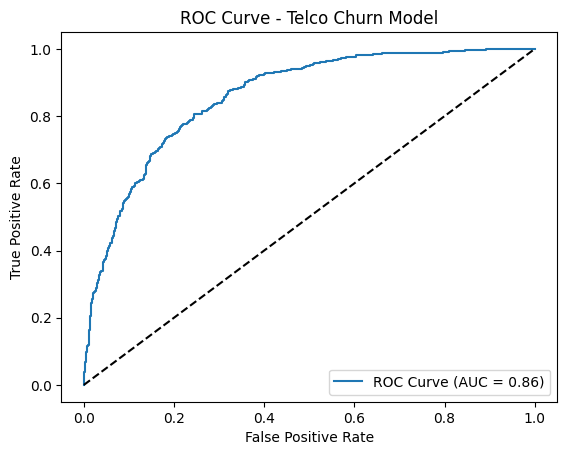

In [15]:
from sklearn.metrics import roc_curve, auc  #ROC
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("ROC AUC Score:", roc_auc)

plt.figure()

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Telco Churn Model")
plt.legend(loc="lower right")

plt.show()

In [16]:
CONTEXT = build_context(df)

print(CONTEXT)

Telco Churn Dataset — 7043 customers, 21 columns
Columns: customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn

Churn rate: 26.5%

Model accuracy: 0.81

Top churn drivers:
Contract            0.424645
OnlineSecurity      0.369047
TechSupport         0.352478
PhoneService        0.208139
PaperlessBilling    0.189484

Churn by Contract:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: object

Avg Monthly Charges:
Churned: $74.44
Retained: $61.27

Avg Tenure:
Churned: 18.0
Retained: 37.6

Churn by Internet Service:
InternetService
DSL            19.0%
Fiber optic    41.9%
No              7.4%
Name: Churn, dtype: object

Churn by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.7%
Credit card (automatic

In [17]:
def ask(question):

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a data analyst. Answer using only the dataset stats provided."},
            {"role": "user",   "content": f"Dataset:\n{CONTEXT}\n\nQuestion: {question}"}
        ],
        max_tokens=300,
    )

    print(f"Q: {question}")
    print("-" * 50)
    print(response.choices[0].message.content.strip())
    print()

In [18]:
ask("Describe the dataset")




Q: Describe the dataset
--------------------------------------------------
This dataset contains information on 7,043 customers from a telecommunications company, with 21 variables describing various aspects of their service and demographics. The primary focus is on customer churn, which occurs at a rate of 26.5%. The dataset includes customer identifiers, demographic information, service details, billing information, and whether the customer churned.

The model used to predict churn achieves an accuracy of 0.81. The most significant factors influencing churn are the type of contract (particularly month-to-month contracts), online security, tech support, phone service, and paperless billing.

Customers who churn tend to have higher monthly charges ($74.44 vs $61.27) and shorter tenures (18.0 months vs 37.6 months) compared to those who remain with the company. Internet service type also plays a role, with fiber optic customers showing the highest churn rate at 41.9%. Payment method is 

In [19]:
ask("What are the high-risk customer characteristics?")


Q: What are the high-risk customer characteristics?
--------------------------------------------------
Based on the dataset statistics, the high-risk customer characteristics for churn are:

1. Contract Type: Month-to-month contract holders have the highest churn rate at 42.7%, compared to 11.3% for one-year contracts and 2.8% for two-year contracts.

2. Internet Service: Customers with fiber optic internet service show a significantly higher churn rate of 41.9%, while DSL customers have a 19.0% churn rate and those without internet service have a 7.4% churn rate.

3. Payment Method: Electronic check users have the highest churn rate at 45.3%, followed by mailed checks at 19.1%, bank transfers at 16.7%, and credit card payments at 15.2%.

4. Service Usage: Customers who do not have online security (69.0% churn rate) and those without tech support (66.2% churn rate) are more likely to churn.

5. Demographics: Senior citizens have a higher churn rate of 40.9% compared to 25.3% for non-se

In [20]:
ask("Which payment method has the highest churn?")

Q: Which payment method has the highest churn?
--------------------------------------------------
Based on the provided dataset, Electronic check has the highest churn rate at 45.3%.

